
virchow2_BLEEP: Found 5 files
  bleep_bleep_virchow2_BC_data_Visium38_D1_3_hvg_cor.csv
    Shape: (988, 1)
    Columns: ['r']
    First few rows:
                r
APOC1    0.265739
S100B    0.264842
ALDH1A3  0.258668
ACP5     0.242431
S100A1   0.241094
    ✓ Loaded 988 genes
  bleep_bleep_virchow2_BC_data_Visium29_C1_4_hvg_cor.csv
    Shape: (988, 1)
    Columns: ['r']
    First few rows:
              r
LY6D   0.206093
WARS   0.204165
PTPRC  0.198602
CXCL9  0.190763
CCL19  0.190437
    ✓ Loaded 988 genes
  bleep_bleep_virchow2_BC_data_Visium38_B1_2_hvg_cor.csv
    Shape: (988, 1)
    Columns: ['r']
    First few rows:
               r
FN1     0.327006
IGLC1   0.315120
FABP5   0.284785
SPRR2G  0.272980
CSTA    0.267099
    ✓ Loaded 988 genes
  bleep_bleep_virchow2_BC_data_Visium37_D1_0_hvg_cor.csv
    Shape: (988, 1)
    Columns: ['r']
    First few rows:
                   r
HLA-DRB1    0.174215
AC138647.1  0.119872
S100B       0.117947
PRSS23      0.114385
FN1         0.111883
    

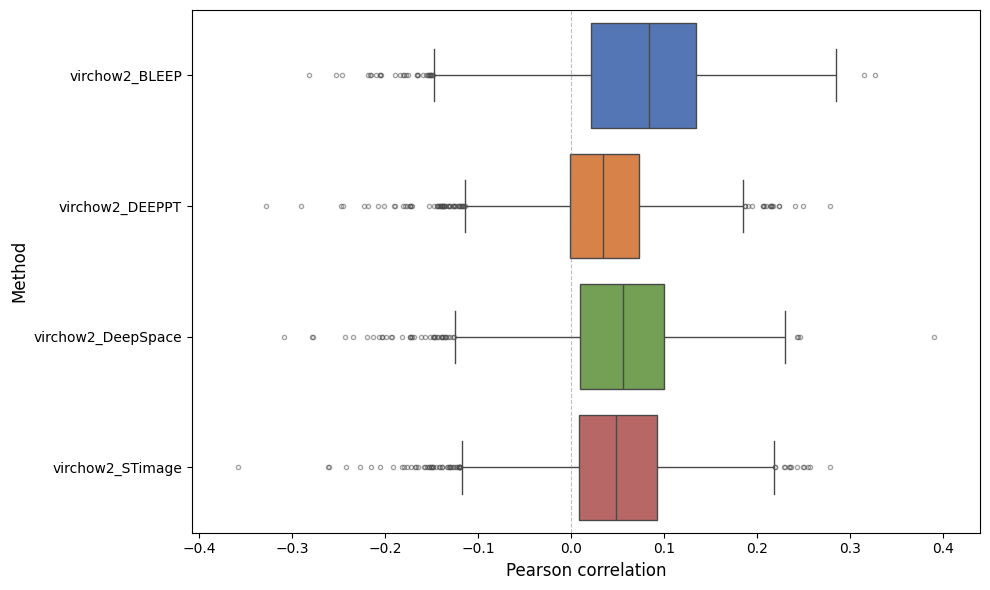


Detailed Statistics by Method:

virchow2_BLEEP:
  Count: 4940
  Mean:   0.0771
  Median: 0.0839
  Std:    0.0791
  Min:    -0.2821
  Max:    0.3270
  Q1:     0.0214
  Q3:     0.1341

virchow2_DEEPPT:
  Count: 4940
  Mean:   0.0335
  Median: 0.0341
  Std:    0.0581
  Min:    -0.3277
  Max:    0.2780
  Q1:     -0.0018
  Q3:     0.0733

virchow2_DeepSpace:
  Count: 4940
  Mean:   0.0530
  Median: 0.0556
  Std:    0.0658
  Min:    -0.3084
  Max:    0.3895
  Q1:     0.0099
  Q3:     0.1000

virchow2_STimage:
  Count: 4940
  Mean:   0.0482
  Median: 0.0486
  Std:    0.0613
  Min:    -0.3579
  Max:    0.2787
  Q1:     0.0082
  Q3:     0.0924


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob

# Define paths for each method
base_path = Path("/QRISdata/Q1851/Xiao/Working_project/benchmarking")
methods = {
    'virchow2_BLEEP': base_path / "BLEEP/Skin_data",
    'virchow2_DEEPPT': base_path / "DEEPPT/Skin_data",
    'virchow2_DeepSpace': base_path / "DeepSpace/Skin_data",
    'virchow2_STimage': base_path / "STimage/Skin_data"
}

# Collect all correlation data
all_correlations = []

for method_name, method_path in methods.items():
    # Find all correlation files for this method
    cor_files = glob.glob(str(method_path / "*_cor.csv"))
    
    print(f"\n{method_name}: Found {len(cor_files)} files")
    
    for cor_file in cor_files:
        try:
            # Read correlation file
            df_cor = pd.read_csv(cor_file, index_col=0)
            
            print(f"  {Path(cor_file).name}")
            print(f"    Shape: {df_cor.shape}")
            print(f"    Columns: {df_cor.columns.tolist()}")
            print(f"    First few rows:")
            print(df_cor.head())
            
            # Check if 'r' column exists
            if 'r' not in df_cor.columns:
                print(f"    WARNING: 'r' column not found! Available columns: {df_cor.columns.tolist()}")
                # Try to find the correlation column
                if len(df_cor.columns) == 1:
                    df_cor.columns = ['r']
                    print(f"    Renamed single column to 'r'")
                elif 'Pearson correlation' in df_cor.columns:
                    # Handle STimage format
                    df_cor = df_cor.rename(columns={'Pearson correlation': 'r'})
                    print(f"    Renamed 'Pearson correlation' to 'r'")
            
            # Reset index to avoid duplicate index issues
            df_cor = df_cor.reset_index()
            
            # Standardize column names
            if len(df_cor.columns) == 2:
                df_cor.columns = ['gene', 'r']
            elif 'r' in df_cor.columns:
                # Keep only gene and r columns if there are extras
                if 'Gene' in df_cor.columns:
                    df_cor = df_cor[['Gene', 'r']]
                    df_cor.columns = ['gene', 'r']
                elif df_cor.columns[0] != 'gene':
                    # First column is likely the gene name
                    gene_col = df_cor.columns[0]
                    df_cor = df_cor[[gene_col, 'r']]
                    df_cor.columns = ['gene', 'r']
            
            # Add method name and file info
            df_cor['Method'] = method_name
            df_cor['File'] = Path(cor_file).stem
            
            all_correlations.append(df_cor)
            print(f"    ✓ Loaded {len(df_cor)} genes")
            
        except Exception as e:
            print(f"    ✗ ERROR loading {Path(cor_file).name}: {e}")

# Combine all data
df_all = pd.concat(all_correlations, axis=0, ignore_index=True)

print(f"\n{'='*60}")
print(f"Total rows: {len(df_all)}")
print(f"\nCorrelation summary by method:")
summary = df_all.groupby('Method')['r'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
print(summary)

# Create the boxplot
fig, ax = plt.subplots(figsize=(10, 6))

# Define colors matching your image
colors = ['#4472C4', '#ED7D31', '#70AD47', '#C55A5A']
method_order = ['virchow2_BLEEP', 'virchow2_DEEPPT', 'virchow2_DeepSpace', 'virchow2_STimage']

# Filter out methods with no data
available_methods = [m for m in method_order if m in df_all['Method'].unique() and 
                     df_all[df_all['Method'] == m]['r'].notna().sum() > 0]
colors_filtered = [colors[method_order.index(m)] for m in available_methods]

print(f"\nAvailable methods for plotting: {available_methods}")

# Create horizontal boxplot using seaborn
sns.boxplot(data=df_all[df_all['Method'].isin(available_methods)], 
            y='Method', x='r', 
            order=available_methods,
            palette=colors_filtered,
            hue='Method',
            legend=False,
            ax=ax,
            showfliers=True,
            flierprops=dict(marker='o', markersize=3, alpha=0.5))

# Customize plot
ax.set_xlabel('Pearson correlation', fontsize=12)
ax.set_ylabel('Method', fontsize=12)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

# Set x-axis limits based on data
if len(available_methods) > 0:
    x_min = df_all[df_all['Method'].isin(available_methods)]['r'].min() - 0.05
    x_max = df_all[df_all['Method'].isin(available_methods)]['r'].max() + 0.05
    ax.set_xlim(x_min, x_max)

plt.tight_layout()
plt.savefig('method_comparison_boxplot.png', dpi=600, bbox_inches='tight')
plt.savefig('method_comparison_boxplot.pdf', bbox_inches='tight')
plt.show()

# Print detailed statistics
print("\n" + "="*60)
print("Detailed Statistics by Method:")
print("="*60)
for method in available_methods:
    method_data = df_all[df_all['Method'] == method]['r']
    print(f"\n{method}:")
    print(f"  Count: {len(method_data)}")
    print(f"  Mean:   {method_data.mean():.4f}")
    print(f"  Median: {method_data.median():.4f}")
    print(f"  Std:    {method_data.std():.4f}")
    print(f"  Min:    {method_data.min():.4f}")
    print(f"  Max:    {method_data.max():.4f}")
    print(f"  Q1:     {method_data.quantile(0.25):.4f}")
    print(f"  Q3:     {method_data.quantile(0.75):.4f}")

In [5]:
import anndata as ad
import scanpy as sc

# Method 1: Using anndata directly
adata_pred = ad.read_h5ad("/QRISdata/Q1851/Xiao/Working_project/benchmarking/DEEPPT/Skin_data/Visium29_B1_deeppt_virchow2_fold_1_predicted.h5ad")

# Method 2: Using scanpy (which uses anndata under the hood)
adata_pred = sc.read_h5ad("/QRISdata/Q1851/Xiao/Working_project/benchmarking/DEEPPT/Skin_data/Visium29_B1_deeppt_virchow2_fold_1_predicted.h5ad")

# Inspect the data
print(f"Shape: {adata_pred.shape}")  # (n_spots, n_genes)
print(f"Number of spots: {adata_pred.n_obs}")
print(f"Number of genes: {adata_pred.n_vars}")
print(f"\nAvailable keys:")
print(f"  obs keys: {adata_pred.obs.keys().tolist()}")
print(f"  var keys: {adata_pred.var.keys().tolist()}")
print(f"  obsm keys: {adata_pred.obsm.keys()}")
print(f"  uns keys: {adata_pred.uns.keys()}")

# View first few genes
print(f"\nFirst 5 genes: {adata_pred.var_names[:5].tolist()}")

# Check if spatial coordinates exist
if 'spatial' in adata_pred.obsm:
    print(f"\nSpatial coordinates available: {adata_pred.obsm['spatial'].shape}")
    print(f"First few coordinates:\n{adata_pred.obsm['spatial'][:3]}")

Shape: (2831, 988)
Number of spots: 2831
Number of genes: 988

Available keys:
  obs keys: ['in_tissue', 'array_row', 'array_col', 'spot_id', 'region', 'library_id']
  var keys: []
  obsm keys: KeysView(AxisArrays with keys: spatial)
  uns keys: dict_keys(['hvg'])

First 5 genes: ['PLEKHN1', 'HES4', 'ISG15', 'UBE2J2', 'FNDC10']

Spatial coordinates available: (2831, 2)
First few coordinates:
[[ 329.46143187 1346.14828508]
 [1224.50758308  462.81286869]
 [ 383.27378419 1068.48684944]]


In [28]:
#upper plot overlay tissue image with spots
#lower plot only spots

In [19]:
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Sample configurations
samples = {
    "Visium29_B1": {"fold": 1},
    "Visium29_C1": {"fold": 4},
    "Visium38_B1": {"fold": 2},
    "Visium38_D1": {"fold": 3},
    "Visium37_D1": {"fold": 0}
}

# Base paths
base_path = Path("/QRISdata/Q1851/Xiao/Working_project/benchmarking")

def get_tissue_image_from_adata(adata_gt, sample_name):
    """Extract hires tissue image from the h5ad file"""
    try:
        library_id = f"{sample_name}_hires_image"
        
        if 'spatial' in adata_gt.uns and library_id in adata_gt.uns['spatial']:
            if 'images' in adata_gt.uns['spatial'][library_id]:
                if 'hires' in adata_gt.uns['spatial'][library_id]['images']:
                    img = adata_gt.uns['spatial'][library_id]['images']['hires']
                    print(f"  Loaded hires image from h5ad: shape = {img.shape}")
                    return img, 1.0
        
        print(f"  Could not find hires image in h5ad")
        return None, 1.0
        
    except Exception as e:
        print(f"  Error extracting image: {e}")
        return None, 1.0

def get_method_paths(method_name, sample_name, fold):
    """Get file paths for each method based on their naming conventions"""
    
    if method_name == 'BLEEP':
        pred_file = f"{sample_name}_bleep_virchow2_BC_data_fold_{fold}_predicted.h5ad"
        cor_file = f"bleep_bleep_virchow2_BC_data_{sample_name}_{fold}_hvg_cor.csv"
        folder = "BLEEP"
        
    elif method_name == 'DEEPPT':
        pred_file = f"{sample_name}_deeppt_virchow2_fold_{fold}_predicted.h5ad"
        cor_file = f"deeppt_deeppt_virchow2_{sample_name}_{fold}_hvg_cor.csv"
        folder = "DEEPPT"
        
    elif method_name == 'DeepSpace':
        pred_file = f"{sample_name}_deepspace_fold_{fold}_predicted.h5ad"
        cor_file = f"deepspace_{sample_name}_{fold}_hvg_cor.csv"
        folder = "DeepSpace"
        
    elif method_name == 'STimage':
        pred_file = f"stimage_stimage_virchow2_{sample_name}_11_hvg.h5"
        cor_file = f"stimage_stimage_virchow2_{sample_name}_11_hvg_cor.csv"
        folder = "STimage"
    
    else:
        raise ValueError(f"Unknown method: {method_name}")
    
    pred_path = base_path / folder / "Skin_data" / pred_file
    cor_path = base_path / folder / "Skin_data" / cor_file
    
    return pred_path, cor_path

def plot_all_methods_comparison(sample_name, fold, gene, tissue_img, adata_gt, 
                                method_predictions, method_correlations):
    """
    Plot tissue image, ground truth, and all method predictions in one row
    """
    # Create figure with 6 subplots (tissue + GT + 4 methods)
    fig, axes = plt.subplots(1, 6, figsize=(30, 5))
    
    # Get ground truth expression
    gt_exp = adata_gt[:, gene].X
    if hasattr(gt_exp, 'toarray'):
        gt_exp = gt_exp.toarray().flatten()
    else:
        gt_exp = gt_exp.flatten()
    
    # Collect all predictions for common color scale
    all_expressions = [gt_exp]
    for method_name, adata_pred in method_predictions.items():
        if adata_pred is not None:
            pred_exp = adata_pred[:, gene].X
            if hasattr(pred_exp, 'toarray'):
                pred_exp = pred_exp.toarray().flatten()
            else:
                pred_exp = pred_exp.flatten()
            all_expressions.append(pred_exp)
    
    # Determine common color scale
    all_exp_concat = np.concatenate(all_expressions)
    vmin = all_exp_concat.min()
    vmax = all_exp_concat.max()
    
    coords = list(method_predictions.values())[0].obsm['spatial']
    
    # 1. Tissue image only
    axes[0].imshow(tissue_img)
    axes[0].set_title('Tissue', fontsize=12, fontweight='bold')
    axes[0].set_xlim(0, tissue_img.shape[1])
    axes[0].set_ylim(tissue_img.shape[0], 0)
    axes[0].axis('off')
    
    # 2. Ground Truth
    axes[1].imshow(tissue_img)
    scatter_gt = axes[1].scatter(coords[:, 0], coords[:, 1], 
                                 c=gt_exp, cmap='viridis', 
                                 s=35, vmin=vmin, vmax=vmax,
                                 edgecolors='white', linewidths=0.2, alpha=0.95)
    axes[1].set_title('Ground Truth', fontsize=12, fontweight='bold')
    axes[1].set_xlim(0, tissue_img.shape[1])
    axes[1].set_ylim(tissue_img.shape[0], 0)
    axes[1].axis('off')
    
    # 3-6. Method predictions
    method_names = ['BLEEP', 'DEEPPT', 'DeepSpace', 'STimage']
    display_names = ['virchow2_BLEEP', 'virchow2_DEEPPT', 'virchow2_DeepSpace', 'virchow2_STimage']
    
    for idx, (method_name, display_name) in enumerate(zip(method_names, display_names)):
        ax = axes[idx + 2]
        
        if method_name in method_predictions and method_predictions[method_name] is not None:
            adata_pred = method_predictions[method_name]
            
            # Get prediction
            pred_exp = adata_pred[:, gene].X
            if hasattr(pred_exp, 'toarray'):
                pred_exp = pred_exp.toarray().flatten()
            else:
                pred_exp = pred_exp.flatten()
            
            # Plot
            ax.imshow(tissue_img)
            scatter = ax.scatter(coords[:, 0], coords[:, 1], 
                               c=pred_exp, cmap='viridis', 
                               s=35, vmin=vmin, vmax=vmax,
                               edgecolors='white', linewidths=0.2, alpha=0.95)
            
            # Get correlation
            corr = method_correlations.get(method_name, np.nan)
            ax.set_title(f'{display_name}\nPCC: {corr:.4f}', 
                        fontsize=12, fontweight='bold')
        else:
            ax.text(0.5, 0.5, 'Not Available', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{display_name}\nN/A', 
                        fontsize=12, fontweight='bold')
        
        ax.set_xlim(0, tissue_img.shape[1])
        ax.set_ylim(tissue_img.shape[0], 0)
        ax.axis('off')
    
    # Add colorbar
    cbar = plt.colorbar(scatter_gt, ax=axes, fraction=0.02, pad=0.02)
    cbar.set_label('Expression', fontsize=12)
    
    # Main title
    fig.suptitle(f'{sample_name} | {gene}', fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    return fig

# Process each sample
for sample_name, config in samples.items():
    fold = config['fold']
    
    print(f"\n{'='*70}")
    print(f"Processing {sample_name} (fold {fold})")
    print(f"{'='*70}")
    
    # Define paths
    gt_path = base_path / "Skin_data" / f"{sample_name}_virchow2.h5ad"
    
    # Load ground truth
    try:
        adata_gt = ad.read_h5ad(str(gt_path))
        print(f"✓ Loaded ground truth: {adata_gt.shape}")
        
        # Get tissue image
        tissue_img, scale_factor = get_tissue_image_from_adata(adata_gt, sample_name)
        
        if tissue_img is None:
            print(f"⚠ Skipping {sample_name} - could not load tissue image")
            continue
        
        # Load predictions from all methods
        method_predictions = {}
        method_correlations = {}
        
        for method_name in ['BLEEP', 'DEEPPT', 'DeepSpace', 'STimage']:
            pred_path, cor_path = get_method_paths(method_name, sample_name, fold)
            
            try:
                if pred_path.exists():
                    adata_pred = ad.read_h5ad(str(pred_path))
                    df_cor = pd.read_csv(str(cor_path), index_col=0)
                    
                    method_predictions[method_name] = adata_pred
                    method_correlations[method_name] = df_cor
                    
                    print(f"✓ Loaded {method_name}: {adata_pred.shape}")
                else:
                    print(f"⚠ {method_name} prediction not found: {pred_path}")
                    method_predictions[method_name] = None
                    
            except Exception as e:
                print(f"✗ Error loading {method_name}: {e}")
                import traceback
                traceback.print_exc()
                method_predictions[method_name] = None
        
        # Get common genes across all methods
        all_gene_sets = []
        for method_name, adata_pred in method_predictions.items():
            if adata_pred is not None:
                all_gene_sets.append(set(adata_pred.var_names))
        
        if len(all_gene_sets) == 0:
            print(f"⚠ No predictions loaded for {sample_name}")
            continue
        
        common_genes = set.intersection(*all_gene_sets)
        print(f"\nCommon genes across all methods: {len(common_genes)}")
        
        # Subset all predictions to common genes
        adata_gt_sub = adata_gt[:, list(common_genes)].copy()
        for method_name in method_predictions.keys():
            if method_predictions[method_name] is not None:
                method_predictions[method_name] = method_predictions[method_name][:, list(common_genes)].copy()
        
        # Get top genes based on average correlation across methods
        avg_correlations = {}
        for gene in common_genes:
            corrs = []
            for method_name, df_cor in method_correlations.items():
                if df_cor is not None and gene in df_cor.index:
                    corrs.append(df_cor.loc[gene, 'r'])
            if corrs:
                avg_correlations[gene] = np.mean(corrs)
        
        # Sort by average correlation
        top_genes = sorted(avg_correlations.items(), key=lambda x: x[1], reverse=True)
        top_gene_names = [g[0] for g in top_genes[:10]]
        
        print(f"\nTop 10 genes by average correlation:")
        for i, (gene, avg_corr) in enumerate(top_genes[:10], 1):
            print(f"  {i}. {gene:15s} : avg r = {avg_corr:.4f}")
        
        # Create output directory
        output_dir = Path(f"spatial_plots_comparison/{sample_name}")
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Plot top 3 genes
        print(f"\nGenerating comparison plots...")
        for gene in top_gene_names[:3]:
            # Get correlations for this gene
            gene_correlations = {}
            for method_name, df_cor in method_correlations.items():
                if df_cor is not None and gene in df_cor.index:
                    gene_correlations[method_name] = df_cor.loc[gene, 'r']
            
            fig = plot_all_methods_comparison(sample_name, fold, gene, tissue_img, 
                                             adata_gt_sub, method_predictions, 
                                             gene_correlations)
            
            output_file = output_dir / f"{sample_name}_{gene}_all_methods.png"
            plt.savefig(output_file, dpi=300, bbox_inches='tight')
            print(f"  ✓ Saved: {output_file}")
            plt.close()
        
    except Exception as e:
        print(f"✗ Error processing {sample_name}: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*70}")
print("All samples processed!")
print(f"{'='*70}")


Processing Visium29_B1 (fold 1)
✓ Loaded ground truth: (2831, 17943)
  Loaded hires image from h5ad: shape = (1768, 2000, 3)
✓ Loaded BLEEP: (2831, 988)
✓ Loaded DEEPPT: (2831, 988)
✓ Loaded DeepSpace: (2831, 988)
✗ Error loading STimage: __init__() got an unexpected keyword argument 'model_weights'

Common genes across all methods: 988

Top 10 genes by average correlation:
  1. MVD             : avg r = 0.2138
  2. TMEM45A         : avg r = 0.1986
  3. S100A2          : avg r = 0.1964
  4. DHCR24          : avg r = 0.1896
  5. LAD1            : avg r = 0.1893
  6. PKP3            : avg r = 0.1820
  7. DSP             : avg r = 0.1818
  8. CSTA            : avg r = 0.1719
  9. TBC1D7          : avg r = 0.1713
  10. CCDC85C         : avg r = 0.1680

Generating comparison plots...


Traceback (most recent call last):
  File "/tmp/ipykernel_546580/1518909035.py", line 200, in <module>
    adata_pred = ad.read_h5ad(str(pred_path))
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/h5ad.py", line 258, in read_h5ad
    adata = read_dispatched(f, callback=callback)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/experimental/_dispatch_io.py", line 42, in read_dispatched
    return reader.read_elem(elem)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/utils.py", line 211, in func_wrapper
    return func(*args, **kwargs)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/specs/registry.py", line 275, in read_elem
    return self.callback(read_func, elem.name, elem, iospec=iospec)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/h5ad.py", line 238, in callback
    return AnnData(
TypeError: __init__() got an unexpected keywor

  ✓ Saved: spatial_plots_comparison/Visium29_B1/Visium29_B1_MVD_all_methods.png
  ✓ Saved: spatial_plots_comparison/Visium29_B1/Visium29_B1_TMEM45A_all_methods.png
  ✓ Saved: spatial_plots_comparison/Visium29_B1/Visium29_B1_S100A2_all_methods.png

Processing Visium29_C1 (fold 4)
✓ Loaded ground truth: (3380, 17943)
  Loaded hires image from h5ad: shape = (1768, 2000, 3)
✓ Loaded BLEEP: (3380, 988)
✓ Loaded DEEPPT: (3380, 988)
✓ Loaded DeepSpace: (3380, 988)
✗ Error loading STimage: __init__() got an unexpected keyword argument 'model_weights'

Common genes across all methods: 988

Top 10 genes by average correlation:
  1. CCL19           : avg r = 0.1822
  2. CXCL9           : avg r = 0.1704
  3. ACP5            : avg r = 0.1616
  4. IVL             : avg r = 0.1612
  5. ARHGAP9         : avg r = 0.1571
  6. IGFL1           : avg r = 0.1558
  7. CLEC10A         : avg r = 0.1531
  8. SDC3            : avg r = 0.1510
  9. NDRG1           : avg r = 0.1467
  10. CNFN            : avg r = 0

Traceback (most recent call last):
  File "/tmp/ipykernel_546580/1518909035.py", line 200, in <module>
    adata_pred = ad.read_h5ad(str(pred_path))
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/h5ad.py", line 258, in read_h5ad
    adata = read_dispatched(f, callback=callback)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/experimental/_dispatch_io.py", line 42, in read_dispatched
    return reader.read_elem(elem)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/utils.py", line 211, in func_wrapper
    return func(*args, **kwargs)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/specs/registry.py", line 275, in read_elem
    return self.callback(read_func, elem.name, elem, iospec=iospec)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/h5ad.py", line 238, in callback
    return AnnData(
TypeError: __init__() got an unexpected keywor

  ✓ Saved: spatial_plots_comparison/Visium29_C1/Visium29_C1_CCL19_all_methods.png
  ✓ Saved: spatial_plots_comparison/Visium29_C1/Visium29_C1_CXCL9_all_methods.png
  ✓ Saved: spatial_plots_comparison/Visium29_C1/Visium29_C1_ACP5_all_methods.png

Processing Visium38_B1 (fold 2)
✓ Loaded ground truth: (3418, 17943)
  Loaded hires image from h5ad: shape = (1924, 2000, 3)
✓ Loaded BLEEP: (3418, 988)
✓ Loaded DEEPPT: (3418, 988)
✓ Loaded DeepSpace: (3418, 988)
✗ Error loading STimage: __init__() got an unexpected keyword argument 'model_weights'

Common genes across all methods: 988

Top 10 genes by average correlation:
  1. FN1             : avg r = 0.2702
  2. MLPH            : avg r = 0.2066
  3. TMEM91          : avg r = 0.1991
  4. MCAM            : avg r = 0.1895
  5. IGLV6-57        : avg r = nan
  6. ZNF106          : avg r = 0.1687
  7. ITPK1           : avg r = 0.1687
  8. SDC3            : avg r = 0.1644
  9. ACOT7           : avg r = 0.1633
  10. SOX10           : avg r = 0.1606

...

  ✓ Saved: spatial_plots_comparison/Visium38_B1/Visium38_B1_FN1_all_methods.png
  ✓ Saved: spatial_plots_comparison/Visium38_B1/Visium38_B1_MLPH_all_methods.png
  ✓ Saved: spatial_plots_comparison/Visium38_B1/Visium38_B1_TMEM91_all_methods.png

Processing Visium38_D1 (fold 3)
✓ Loaded ground truth: (2539, 17943)
  Loaded hires image from h5ad: shape = (1923, 2000, 3)
✓ Loaded BLEEP: (2539, 988)
✓ Loaded DEEPPT: (2539, 988)
✓ Loaded DeepSpace: (2539, 988)
✗ Error loading STimage: __init__() got an unexpected keyword argument 'model_weights'

Common genes across all methods: 988

Top 10 genes by average correlation:
  1. APOC1           : avg r = 0.2449
  2. ACP5            : avg r = 0.2182
  3. PCDH7           : avg r = 0.2128
  4. CSTA            : avg r = 0.1993
  5. SDC3            : avg r = 0.1966
  6. ETV5            : avg r = 0.1886
  7. MLPH            : avg r = 0.1885
  8. KRT2            : avg r = 0.1836
  9. DSTYK           : avg r = 0.1768
  10. PNPLA5          : avg r = nan


Traceback (most recent call last):
  File "/tmp/ipykernel_546580/1518909035.py", line 200, in <module>
    adata_pred = ad.read_h5ad(str(pred_path))
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/h5ad.py", line 258, in read_h5ad
    adata = read_dispatched(f, callback=callback)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/experimental/_dispatch_io.py", line 42, in read_dispatched
    return reader.read_elem(elem)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/utils.py", line 211, in func_wrapper
    return func(*args, **kwargs)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/specs/registry.py", line 275, in read_elem
    return self.callback(read_func, elem.name, elem, iospec=iospec)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/h5ad.py", line 238, in callback
    return AnnData(
TypeError: __init__() got an unexpected keywor

  ✓ Saved: spatial_plots_comparison/Visium38_D1/Visium38_D1_APOC1_all_methods.png
  ✓ Saved: spatial_plots_comparison/Visium38_D1/Visium38_D1_ACP5_all_methods.png
  ✓ Saved: spatial_plots_comparison/Visium38_D1/Visium38_D1_PCDH7_all_methods.png

Processing Visium37_D1 (fold 0)
✓ Loaded ground truth: (3041, 17943)
  Loaded hires image from h5ad: shape = (2000, 1934, 3)
✓ Loaded BLEEP: (3041, 988)
✓ Loaded DEEPPT: (3041, 988)
✓ Loaded DeepSpace: (3041, 988)
✗ Error loading STimage: __init__() got an unexpected keyword argument 'model_weights'

Common genes across all methods: 988

Top 10 genes by average correlation:
  1. SLC24A5         : avg r = 0.0923
  2. PHACTR1         : avg r = 0.0703
  3. MLPH            : avg r = 0.0671
  4. CAV1            : avg r = 0.0632
  5. PMEPA1          : avg r = 0.0605
  6. IGFL1           : avg r = 0.0599
  7. ITPK1           : avg r = 0.0592
  8. MAGED2          : avg r = 0.0550
  9. SPRR1B          : avg r = 0.0530
  10. ZNF106          : avg r = 0.0

Traceback (most recent call last):
  File "/tmp/ipykernel_546580/1518909035.py", line 200, in <module>
    adata_pred = ad.read_h5ad(str(pred_path))
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/h5ad.py", line 258, in read_h5ad
    adata = read_dispatched(f, callback=callback)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/experimental/_dispatch_io.py", line 42, in read_dispatched
    return reader.read_elem(elem)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/utils.py", line 211, in func_wrapper
    return func(*args, **kwargs)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/specs/registry.py", line 275, in read_elem
    return self.callback(read_func, elem.name, elem, iospec=iospec)
  File "/home/uqhngu61/.conda/envs/hest/lib/python3.9/site-packages/anndata/_io/h5ad.py", line 238, in callback
    return AnnData(
TypeError: __init__() got an unexpected keywor

  ✓ Saved: spatial_plots_comparison/Visium37_D1/Visium37_D1_SLC24A5_all_methods.png
  ✓ Saved: spatial_plots_comparison/Visium37_D1/Visium37_D1_PHACTR1_all_methods.png
  ✓ Saved: spatial_plots_comparison/Visium37_D1/Visium37_D1_MLPH_all_methods.png

All samples processed!


In [27]:
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Sample configurations
samples = {
    "Visium29_B1": {"fold": 1},
    "Visium29_C1": {"fold": 4},
    "Visium38_B1": {"fold": 2},
    "Visium38_D1": {"fold": 3},
    "Visium37_D1": {"fold": 0}
}

# Base paths
base_path = Path("/QRISdata/Q1851/Xiao/Working_project/benchmarking")

def get_tissue_image_from_adata(adata_gt, sample_name):
    """Extract hires tissue image from the h5ad file"""
    try:
        library_id = f"{sample_name}_hires_image"
        
        if 'spatial' in adata_gt.uns and library_id in adata_gt.uns['spatial']:
            if 'images' in adata_gt.uns['spatial'][library_id]:
                if 'hires' in adata_gt.uns['spatial'][library_id]['images']:
                    img = adata_gt.uns['spatial'][library_id]['images']['hires']
                    print(f"  Loaded hires image from h5ad: shape = {img.shape}")
                    return img, 1.0
        
        print(f"  Could not find hires image in h5ad")
        return None, 1.0
        
    except Exception as e:
        print(f"  Error extracting image: {e}")
        return None, 1.0

def get_method_paths(method_name, sample_name, fold):
    """Get file paths for each method based on their naming conventions"""
    
    if method_name == 'BLEEP':
        pred_file = f"{sample_name}_bleep_virchow2_BC_data_fold_{fold}_predicted.h5ad"
        cor_file = f"bleep_bleep_virchow2_BC_data_{sample_name}_{fold}_hvg_cor.csv"
        mtx_file = None
        folder = "BLEEP"
        
    elif method_name == 'DEEPPT':
        pred_file = f"{sample_name}_deeppt_virchow2_fold_{fold}_predicted.h5ad"
        cor_file = f"deeppt_deeppt_virchow2_{sample_name}_{fold}_hvg_cor.csv"
        mtx_file = None
        folder = "DEEPPT"
        
    elif method_name == 'DeepSpace':
        pred_file = f"{sample_name}_deepspace_fold_{fold}_predicted.h5ad"
        cor_file = f"deepspace_{sample_name}_{fold}_hvg_cor.csv"
        mtx_file = None
        folder = "DeepSpace"
        
    elif method_name == 'STimage':
        pred_file = None  # We'll use the matrix CSV instead
        cor_file = f"stimage_stimage_virchow2_{sample_name}_11_hvg_cor.csv"
        mtx_file = f"stimage_stimage_virchow2_{sample_name}_11_hvg_mtx.csv"
        folder = "STimage"
    
    else:
        raise ValueError(f"Unknown method: {method_name}")
    
    pred_path = base_path / folder / "Skin_data" / pred_file if pred_file else None
    cor_path = base_path / folder / "Skin_data" / cor_file
    mtx_path = base_path / folder / "Skin_data" / mtx_file if mtx_file else None
    
    return pred_path, cor_path, mtx_path

def load_stimage_from_csv(mtx_path, adata_reference):
    """Load STimage prediction from CSV matrix file"""
    try:
        # Read the matrix CSV
        df_mtx = pd.read_csv(mtx_path, index_col=0)
        print(f"    ✓ Loaded matrix CSV: {df_mtx.shape}")
        
        # Create AnnData object matching the reference structure
        adata = ad.AnnData(
            X=df_mtx.values,
            obs=adata_reference.obs.copy(),
            var=pd.DataFrame(index=df_mtx.columns),
            obsm={'spatial': adata_reference.obsm['spatial'].copy()}
        )
        
        print(f"    ✓ Created AnnData from CSV: {adata.shape}")
        return adata
        
    except Exception as e:
        print(f"    ✗ Error loading STimage from CSV: {e}")
        return None

def load_correlation_file(cor_path, method_name):
    """Load correlation file with method-specific handling"""
    try:
        df_cor = pd.read_csv(cor_path)
        
        if method_name == 'STimage':
            # STimage format: ['Gene', 'Pearson correlation', 'Slide', 'Method']
            if 'Gene' in df_cor.columns and 'Pearson correlation' in df_cor.columns:
                df_cor = df_cor.set_index('Gene')
                df_cor = df_cor.rename(columns={'Pearson correlation': 'r'})
                df_cor = df_cor[['r']]
                print(f"    Converted STimage format to standard format")
            else:
                print(f"    Warning: STimage file has unexpected format: {df_cor.columns.tolist()}")
        else:
            # Standard format
            if df_cor.columns[0] != 'r':
                df_cor = df_cor.set_index(df_cor.columns[0])
        
        print(f"    Loaded correlations: {df_cor.shape}, columns: {df_cor.columns.tolist()}")
        return df_cor
        
    except Exception as e:
        print(f"    Error loading correlation file: {e}")
        return None

def plot_all_methods_comparison(sample_name, fold, gene, tissue_img, adata_gt, 
                                method_predictions, method_correlations):
    """Plot tissue image, ground truth, and all method predictions in one row"""
    fig, axes = plt.subplots(1, 6, figsize=(30, 5))
    
    # Get ground truth expression
    gt_exp = adata_gt[:, gene].X
    if hasattr(gt_exp, 'toarray'):
        gt_exp = gt_exp.toarray().flatten()
    else:
        gt_exp = gt_exp.flatten()
    
    # Collect all predictions for common color scale
    all_expressions = [gt_exp]
    for method_name, adata_pred in method_predictions.items():
        if adata_pred is not None:
            pred_exp = adata_pred[:, gene].X
            if hasattr(pred_exp, 'toarray'):
                pred_exp = pred_exp.toarray().flatten()
            else:
                pred_exp = pred_exp.flatten()
            all_expressions.append(pred_exp)
    
    # Determine common color scale
    all_exp_concat = np.concatenate(all_expressions)
    vmin = all_exp_concat.min()
    vmax = all_exp_concat.max()
    
    # Get coordinates
    coords = None
    for adata_pred in method_predictions.values():
        if adata_pred is not None:
            coords = adata_pred.obsm['spatial']
            break
    
    if coords is None:
        print("Warning: No coordinates found!")
        return None
    
    # 1. Tissue image only
    axes[0].imshow(tissue_img)
    axes[0].set_title('Tissue', fontsize=12, fontweight='bold')
    axes[0].set_xlim(0, tissue_img.shape[1])
    axes[0].set_ylim(tissue_img.shape[0], 0)
    axes[0].axis('off')
    
    # 2. Ground Truth
    axes[1].scatter(coords[:, 0], coords[:, 1], 
                    c=gt_exp, cmap='viridis', 
                    s=25, vmin=vmin, vmax=vmax,
                    edgecolors='white', linewidths=0.1, alpha=0.95)
    axes[1].set_title('Ground Truth', fontsize=12, fontweight='bold')
    axes[1].set_xlim(0, tissue_img.shape[1])
    axes[1].set_ylim(tissue_img.shape[0], 0)
    axes[1].set_facecolor('white')
    axes[1].axis('off')
    axes[1].set_aspect('equal')
    
    # 3-6. Method predictions
    method_names = ['BLEEP', 'DEEPPT', 'DeepSpace', 'STimage']
    display_names = ['virchow2_BLEEP', 'virchow2_DEEPPT', 'virchow2_DeepSpace', 'virchow2_STimage']
    
    for idx, (method_name, display_name) in enumerate(zip(method_names, display_names)):
        ax = axes[idx + 2]
        
        if method_name in method_predictions and method_predictions[method_name] is not None:
            adata_pred = method_predictions[method_name]
            
            # Get prediction
            pred_exp = adata_pred[:, gene].X
            if hasattr(pred_exp, 'toarray'):
                pred_exp = pred_exp.toarray().flatten()
            else:
                pred_exp = pred_exp.flatten()
            
            # Plot spots only
            ax.scatter(coords[:, 0], coords[:, 1], 
                      c=pred_exp, cmap='viridis', 
                      s=25, vmin=vmin, vmax=vmax,
                      edgecolors='white', linewidths=0.1, alpha=0.95)
            
            # Get correlation
            corr = method_correlations.get(method_name, np.nan)
            ax.set_title(f'{display_name}\nPCC: {corr:.4f}', 
                        fontsize=12, fontweight='bold')
        else:
            ax.text(0.5, 0.5, 'Not Available', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{display_name}\nN/A', 
                        fontsize=12, fontweight='bold')
        
        ax.set_xlim(0, tissue_img.shape[1])
        ax.set_ylim(tissue_img.shape[0], 0)
        ax.set_facecolor('white')
        ax.axis('off')
        ax.set_aspect('equal')
    
    # Main title
    fig.suptitle(f'{sample_name} | {gene}', fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    return fig

# Process each sample
for sample_name, config in samples.items():
    fold = config['fold']
    
    print(f"\n{'='*70}")
    print(f"Processing {sample_name} (fold {fold})")
    print(f"{'='*70}")
    
    # Load ground truth
    gt_path = base_path / "Skin_data" / f"{sample_name}_virchow2.h5ad"
    
    try:
        adata_gt = ad.read_h5ad(str(gt_path))
        print(f"✓ Loaded ground truth: {adata_gt.shape}")
        
        # Get tissue image
        tissue_img, scale_factor = get_tissue_image_from_adata(adata_gt, sample_name)
        
        if tissue_img is None:
            print(f"⚠ Skipping {sample_name} - could not load tissue image")
            continue
        
        # Load predictions from all methods
        method_predictions = {}
        method_correlations = {}
        
        for method_name in ['BLEEP', 'DEEPPT', 'DeepSpace', 'STimage']:
            pred_path, cor_path, mtx_path = get_method_paths(method_name, sample_name, fold)
            
            print(f"\n  Loading {method_name}:")
            try:
                # Load prediction data
                if method_name == 'STimage':
                    # Load from CSV matrix
                    if mtx_path and mtx_path.exists():
                        adata_pred = load_stimage_from_csv(mtx_path, adata_gt)
                    else:
                        print(f"    ⚠ Matrix file not found: {mtx_path.name if mtx_path else 'N/A'}")
                        adata_pred = None
                else:
                    # Load from h5ad
                    if pred_path and pred_path.exists():
                        adata_pred = ad.read_h5ad(str(pred_path))
                        print(f"    ✓ Prediction file: {adata_pred.shape}")
                    else:
                        print(f"    ⚠ Prediction file not found")
                        adata_pred = None
                
                if adata_pred is not None:
                    # Load correlation file
                    df_cor = load_correlation_file(cor_path, method_name)
                    
                    if df_cor is not None:
                        method_predictions[method_name] = adata_pred
                        method_correlations[method_name] = df_cor
                        print(f"    ✓ Successfully loaded {method_name}")
                    else:
                        print(f"    ✗ Failed to load correlations")
                        method_predictions[method_name] = None
                else:
                    method_predictions[method_name] = None
                    
            except Exception as e:
                print(f"    ✗ Error loading {method_name}: {e}")
                import traceback
                traceback.print_exc()
                method_predictions[method_name] = None
        
        # Get common genes
        all_gene_sets = []
        for method_name, adata_pred in method_predictions.items():
            if adata_pred is not None:
                all_gene_sets.append(set(adata_pred.var_names))
        
        if len(all_gene_sets) == 0:
            print(f"\n⚠ No predictions loaded for {sample_name}")
            continue
        
        common_genes = set.intersection(*all_gene_sets)
        print(f"\n✓ Common genes across all methods: {len(common_genes)}")
        
        # Subset to common genes
        adata_gt_sub = adata_gt[:, list(common_genes)].copy()
        for method_name in method_predictions.keys():
            if method_predictions[method_name] is not None:
                method_predictions[method_name] = method_predictions[method_name][:, list(common_genes)].copy()
        
        # Get top genes by average correlation
        avg_correlations = {}
        for gene in common_genes:
            corrs = []
            for method_name, df_cor in method_correlations.items():
                if df_cor is not None and gene in df_cor.index:
                    corrs.append(df_cor.loc[gene, 'r'])
            if corrs:
                avg_correlations[gene] = np.mean(corrs)
        
        top_genes = sorted(avg_correlations.items(), key=lambda x: x[1], reverse=True)
        top_gene_names = [g[0] for g in top_genes[:10]]
        
        print(f"\nTop 10 genes by average correlation:")
        for i, (gene, avg_corr) in enumerate(top_genes[:10], 1):
            print(f"  {i}. {gene:15s} : avg r = {avg_corr:.4f}")
        
        # Create output directory
        output_dir = Path(f"spatial_plots_comparison/{sample_name}")
        output_dir.mkdir(parents=True, exist_ok=True)
        
        # Plot top 3 genes
        print(f"\nGenerating comparison plots...")
        for gene in top_gene_names[:3]:
            # Get correlations for this gene
            gene_correlations = {}
            for method_name, df_cor in method_correlations.items():
                if df_cor is not None and gene in df_cor.index:
                    gene_correlations[method_name] = df_cor.loc[gene, 'r']
            
            fig = plot_all_methods_comparison(sample_name, fold, gene, tissue_img, 
                                             adata_gt_sub, method_predictions, 
                                             gene_correlations)
            
            if fig is not None:
                output_file = output_dir / f"{sample_name}_{gene}_all_methods.png"
                plt.savefig(output_file, dpi=600, bbox_inches='tight')
                print(f"  ✓ Saved: {output_file}")
                plt.close()
        
    except Exception as e:
        print(f"✗ Error processing {sample_name}: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*70}")
print("All samples processed!")
print(f"{'='*70}")


Processing Visium29_B1 (fold 1)
✓ Loaded ground truth: (2831, 17943)
  Loaded hires image from h5ad: shape = (1768, 2000, 3)

  Loading BLEEP:
    ✓ Prediction file: (2831, 988)
    Loaded correlations: (988, 1), columns: ['r']
    ✓ Successfully loaded BLEEP

  Loading DEEPPT:
    ✓ Prediction file: (2831, 988)
    Loaded correlations: (988, 1), columns: ['r']
    ✓ Successfully loaded DEEPPT

  Loading DeepSpace:
    ✓ Prediction file: (2831, 988)
    Loaded correlations: (988, 1), columns: ['r']
    ✓ Successfully loaded DeepSpace

  Loading STimage:
    ✓ Loaded matrix CSV: (2831, 988)
    ✓ Created AnnData from CSV: (2831, 988)
    Converted STimage format to standard format
    Loaded correlations: (988, 1), columns: ['r']
    ✓ Successfully loaded STimage

✓ Common genes across all methods: 988

Top 10 genes by average correlation:
  1. MVD             : avg r = 0.2193
  2. TMEM45A         : avg r = 0.1868
  3. LAD1            : avg r = 0.1832
  4. PKP3            : avg r = 0.1